In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import Normalize, ListedColormap
from matplotlib.lines import Line2D
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [18]:
import warnings # ignore warnings
warnings.filterwarnings('ignore')

In [19]:
# Let's load our dataset
df = pd.read_csv('C:/Users/HP/OneDrive/7CS030/Assessment/country_data.csv')

In [20]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [21]:
df.info

<bound method DataFrame.info of                  country  child_mort  exports  health  imports  income  \
0            Afghanistan        90.2     10.0    7.58     44.9    1610   
1                Albania        16.6     28.0    6.55     48.6    9930   
2                Algeria        27.3     38.4    4.17     31.4   12900   
3                 Angola       119.0     62.3    2.85     42.9    5900   
4    Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   
..                   ...         ...      ...     ...      ...     ...   
162              Vanuatu        29.2     46.6    5.25     52.7    2950   
163            Venezuela        17.1     28.5    4.91     17.6   16500   
164              Vietnam        23.3     72.0    6.84     80.2    4490   
165                Yemen        56.3     30.0    5.18     34.4    4480   
166               Zambia        83.1     37.0    5.89     30.9    3280   

     inflation  life_expec  total_fer   gdpp  
0         9.44        56.2      

In [22]:
df.describe

<bound method NDFrame.describe of                  country  child_mort  exports  health  imports  income  \
0            Afghanistan        90.2     10.0    7.58     44.9    1610   
1                Albania        16.6     28.0    6.55     48.6    9930   
2                Algeria        27.3     38.4    4.17     31.4   12900   
3                 Angola       119.0     62.3    2.85     42.9    5900   
4    Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   
..                   ...         ...      ...     ...      ...     ...   
162              Vanuatu        29.2     46.6    5.25     52.7    2950   
163            Venezuela        17.1     28.5    4.91     17.6   16500   
164              Vietnam        23.3     72.0    6.84     80.2    4490   
165                Yemen        56.3     30.0    5.18     34.4    4480   
166               Zambia        83.1     37.0    5.89     30.9    3280   

     inflation  life_expec  total_fer   gdpp  
0         9.44        56.2    

In [23]:
df.isna().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [24]:
# ### DATA VISUALIZATION AND ANALYSIS

# Let's drop the country column first
df_corr= df.drop(df.columns[0], axis=1) 
df_corr.corr()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
child_mort,1.000000,-0.318093,-0.200402,-0.127211,-0.524315,0.288276,-0.886676,0.848478,-0.483032
exports,-0.318093,1.000000,-0.114408,0.737381,0.516784,-0.107294,0.316313,-0.320011,0.418725
health,-0.200402,-0.114408,1.000000,0.095717,0.129579,-0.255376,0.210692,-0.196674,0.345966
imports,-0.127211,0.737381,0.095717,1.000000,0.122406,-0.246994,0.054391,-0.159048,0.115498
income,-0.524315,0.516784,0.129579,0.122406,1.000000,-0.147756,0.611962,-0.501840,0.895571
inflation,0.288276,-0.107294,-0.255376,-0.246994,-0.147756,1.000000,-0.239705,0.316921,-0.221631
life_expec,-0.886676,0.316313,0.210692,0.054391,0.611962,-0.239705,1.000000,-0.760875,0.600089
total_fer,0.848478,-0.320011,-0.196674,-0.159048,-0.501840,0.316921,-0.760875,1.000000,-0.454910
gdpp,-0.483032,0.418725,0.345966,0.115498,0.895571,-0.221631,0.600089,-0.454910,1.000000


In [28]:
# Then we proceed to print scaled dataset
# This is crucial for clustering as features have different scales
scaled = StandardScaler().fit_transform(df_corr)
df_scaled = pd.DataFrame(data = scaled, columns=df.columns[1:])
df_scaled

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817
...,...,...,...,...,...,...,...,...,...
162,-0.225578,0.200917,-0.571711,0.240700,-0.738527,-0.489784,-0.852161,0.365754,-0.546913
163,-0.526514,-0.461363,-0.695862,-1.213499,-0.033542,3.616865,0.546361,-0.316678,0.029323
164,-0.372315,1.130305,0.008877,1.380030,-0.658404,0.409732,0.286958,-0.661206,-0.637754
165,0.448417,-0.406478,-0.597272,-0.517472,-0.658924,1.500916,-0.344633,1.140944,-0.637754


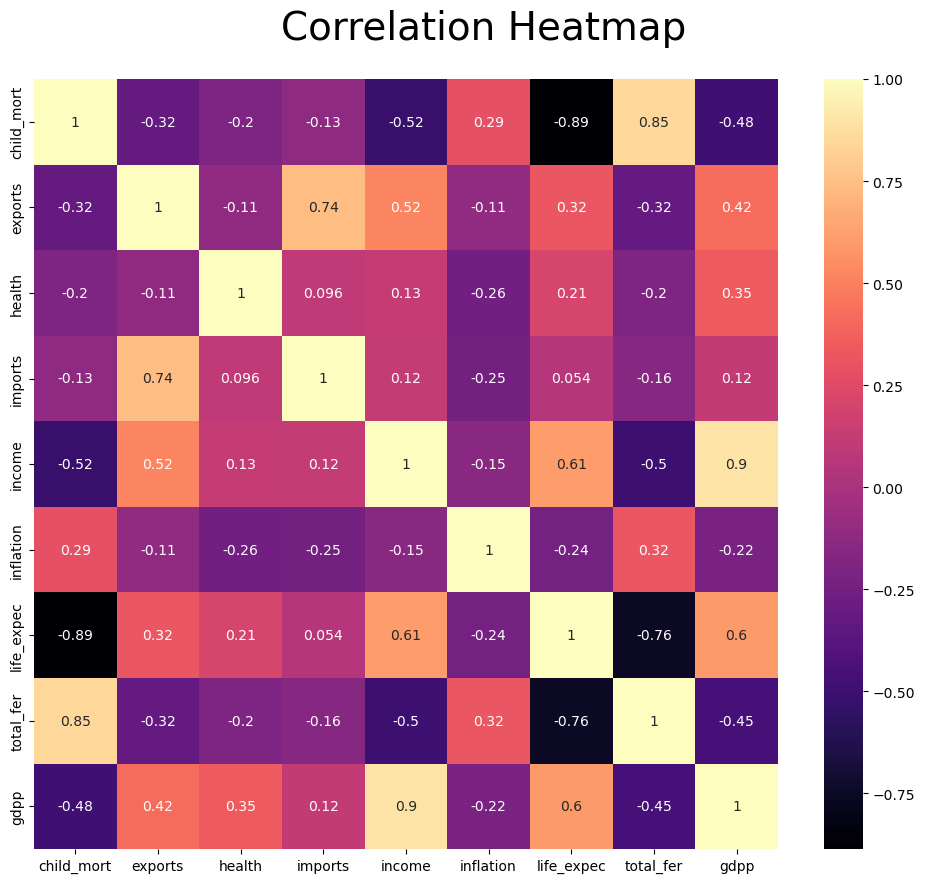

In [27]:
# Next we visualize through the correlation heatmap
corr = df_corr.corr()
fig, ax=plt.subplots(figsize=(12,10))
fig.suptitle('Correlation Heatmap', fontsize=28, y=.95)
heatmap = sns.heatmap(corr, cmap='magma', annot=True)

In [29]:
# we select the normalized child_mort & income columns 
X = df_scaled.iloc[:, [0,4]].values
X.shape

(167, 2)

In [30]:
print(X[:,0])

[ 1.29153238 -0.5389489  -0.27283273  2.00780766 -0.69563412 -0.5911773
 -0.50164289 -0.8324228  -0.84485813  0.02312823 -0.60858677 -0.73791425
  0.27680906 -0.5986385  -0.81501333 -0.839884   -0.48423342  1.8088423
  0.11017558  0.20717119 -0.78019439  0.35390814 -0.45936275 -0.69065998
 -0.68319878  1.93319565  1.37609265  0.15245571  1.73423029 -0.81252626
 -0.29272927  2.75392774  2.77879841 -0.73542719 -0.5613325  -0.48920756
  1.24179104  1.93319565  0.63743377 -0.69812118  1.8088423  -0.81501333
 -0.8622676  -0.86724173 -0.84983227 -0.09625098 -0.32754821 -0.22806553
 -0.47428516  1.8088423   0.42105895 -0.839884   -0.35241888 -0.87719
 -0.8473452   0.63245964  1.04531275 -0.54143596 -0.8473452   0.906037
 -0.8548064  -0.58869024 -0.07138031  1.75910096  1.88345431 -0.01666484
  4.22129724 -0.80257799 -0.88713827  0.51059336 -0.12360872 -0.47179809
 -0.03407431 -0.8473452  -0.83739693 -0.85231933 -0.50164289 -0.87221587
 -0.42703088 -0.41708262  0.59515363  0.60758897 -0.683198

In [31]:
#  second column income
X[:,1]

array([-8.08245403e-01, -3.75368896e-01, -2.20844469e-01, -5.85043454e-01,
        1.01731774e-01,  8.09204035e-02, -5.43420713e-01,  1.26196568e+00,
        1.35561685e+00, -5.95563477e-02,  2.99439794e-01,  1.24635715e+00,
       -7.65061809e-01, -9.59762462e-02, -4.91506624e-02,  1.24635715e+00,
       -4.82027170e-01, -7.97319434e-01, -5.57988672e-01, -6.10537383e-01,
       -3.86294865e-01, -2.00033099e-01, -1.37598987e-01,  3.30148000e+00,
       -9.59762462e-02, -8.17610520e-01, -8.52261452e-01, -7.60899535e-01,
       -7.53615555e-01,  1.22554578e+00, -5.88685444e-01, -8.45809927e-01,
       -7.91596307e-01,  1.17340302e-01, -3.96180266e-01, -3.24901322e-01,
       -8.18651088e-01, -8.60325858e-01, -6.21983637e-01, -2.15641627e-01,
       -7.52054703e-01,  1.53760200e-01,  8.71752484e-01,  5.80393297e-01,
        1.39723959e+00, -3.14495637e-01, -4.05545383e-01, -3.79010886e-01,
       -5.12203657e-01,  8.61346799e-01, -8.18130804e-01,  2.89034109e-01,
       -5.09602236e-01,  

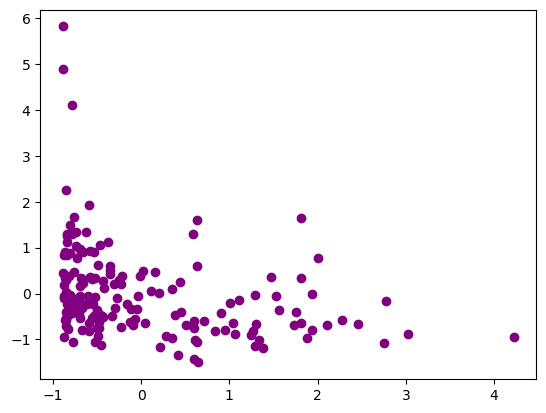

In [59]:
# Let's visualize the clusters
scatter1 = plt.scatter(X[:,0], X[:,1], c ="purple")
plt.savefig('Cluster_plot_before_training.png')
plt.show()


In [36]:
# create model
model = KMeans(n_clusters=3, random_state=42)
model.fit(X)

KMeans(n_clusters=3, random_state=42)

In [37]:
centers = model.cluster_centers_
print(centers)

[[-0.28254538 -0.33321492]
 [ 1.69451037 -0.73356472]
 [-0.8097774   1.48938467]]


In [38]:
kmeans = KMeans(n_clusters=3, random_state=0).fit(X)
kmcenters = kmeans.cluster_centers_
print(kmcenters)

[[-0.81045371  1.72415154]
 [ 1.40296379 -0.7145456 ]
 [-0.44200795 -0.20720273]]


In [39]:
cluster_centers = model.cluster_centers_

# we print the cluster centers
centers = model.cluster_centers_
print('Centroids:', centers, '\n')
model.labels_

Centroids: [[-0.28254538 -0.33321492]
 [ 1.69451037 -0.73356472]
 [-0.8097774   1.48938467]] 



array([1, 0, 0, 1, 0, 0, 0, 2, 2, 0, 0, 2, 0, 0, 0, 2, 0, 1, 0, 0, 0, 0,
       0, 2, 0, 1, 1, 0, 1, 2, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 2, 2,
       2, 0, 0, 0, 0, 1, 0, 0, 0, 2, 2, 0, 1, 0, 2, 1, 2, 0, 0, 1, 1, 0,
       1, 0, 2, 0, 0, 0, 0, 2, 2, 2, 0, 2, 0, 0, 0, 0, 2, 0, 1, 0, 0, 1,
       1, 2, 0, 2, 0, 0, 1, 0, 0, 1, 2, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       2, 2, 1, 1, 2, 2, 1, 0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 2, 1, 0, 0,
       1, 2, 0, 2, 0, 0, 2, 2, 0, 0, 1, 0, 2, 2, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 2, 2, 2, 0, 0, 0, 0, 0, 0, 1], dtype=int32)

In [40]:
df['cluster'] = model.labels_
df.head(10)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200,0
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300,0
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220,0
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900,2
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900,2
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840,0


In [41]:
df.cluster.value_counts()

cluster
0    95
2    38
1    34
Name: count, dtype: int64

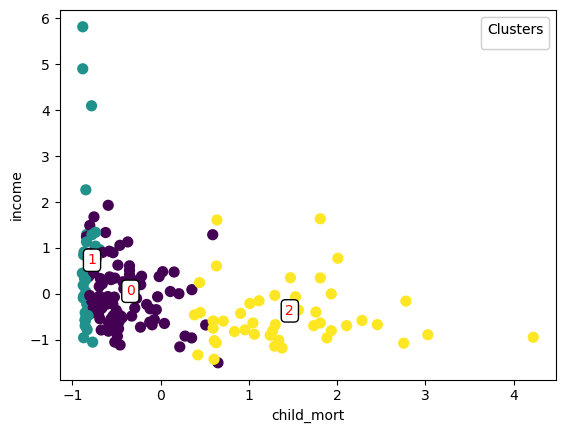

In [60]:
# Time to visualize
scatter2, ax = plt.subplots()

# We store the normaliz=sation of color endings
nm = Normalize(vmin = 0, vmax = len(centers)-1)

# For the clustered data
Scatter1 = ax.scatter(X[:, 0], X[:, 1],
	c = model.predict(X), s = 50, cmap = 'viridis', norm = nm)

# we plot the centroids 
for i in range(centers.shape[0]):
	ax.text(centers[i, 0], centers[i, 1], str(i), c = 'red',
		bbox=dict(boxstyle="round", facecolor='white', edgecolor='black'))

# Labelling the X & Y-axis
ax.set_xlabel(df.columns[1])
ax.set_ylabel(df.columns[5])

# ensuring the Legend reflects the unique colors on the cluster plot
legend1 = ax.legend(*scatter1.legend_elements(),
                    loc="upper right", title="Clusters")
ax.add_artist(legend1)
scatter2.savefig('Cluster_plot.png')


In [46]:
X = df_scaled.iloc[:, [0,4,5,8 ]].values
X.shape

(167, 4)

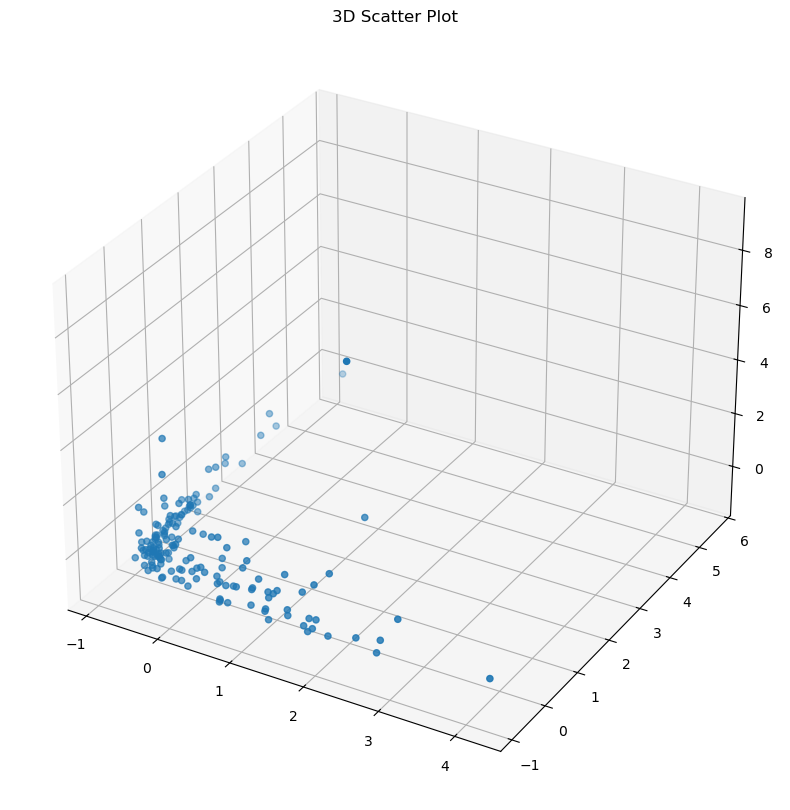

In [47]:
# 3D Plot to observe the number of clusters to be selected 

scatter3 = plt.figure(figsize = (10, 10))
ax = plt.axes(projection ="3d")
 
# Creating plot
ax.scatter3D(X[:,0], X[:,1], X[:,2],cmap = 'viridis')
plt.title("3D Scatter Plot")
scatter3.savefig('Cluster_initial_plot.png')
plt.show()

In [48]:
model = KMeans(n_clusters = 3, n_init='auto', random_state=42)
model.fit(X)

KMeans(n_clusters=3, random_state=42)

In [49]:
model.labels_
df['cluster'] = model.labels_
df.head(20)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553,2
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530,2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200,0
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300,0
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220,0
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900,1
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900,1
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840,0


In [50]:
df.cluster.value_counts()

cluster
0    90
2    45
1    32
Name: count, dtype: int64

In [51]:
# print the centers
cluster_centers = model.cluster_centers_
centers = model.cluster_centers_
print('Centroids:', centers, '\n')

Centroids: [[-0.39041573 -0.23944174 -0.18366468 -0.32073337]
 [-0.8126817   1.65543066 -0.37288448  1.75806697]
 [ 1.35873845 -0.69831165  0.63249165 -0.60871422]] 



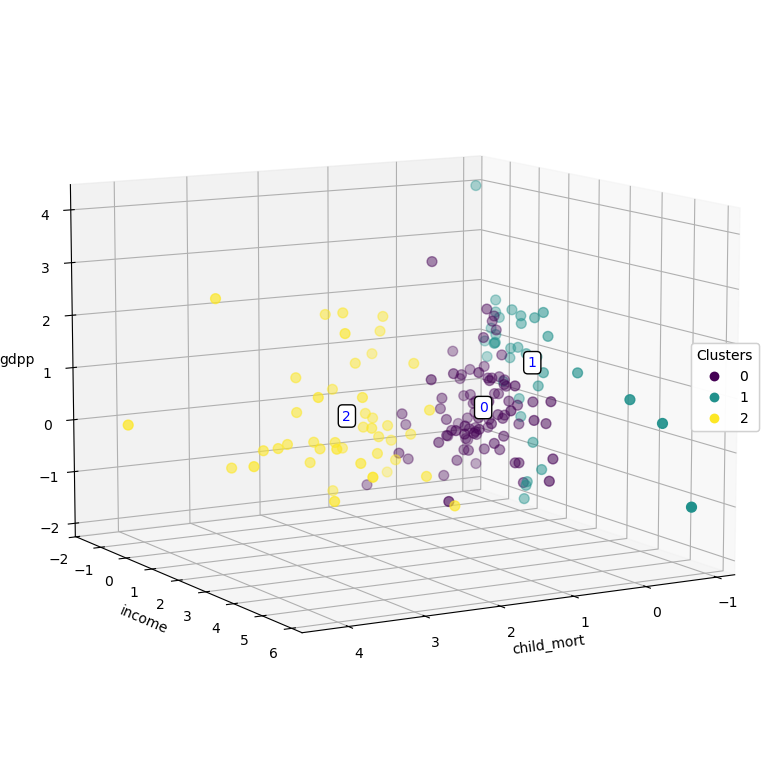

In [61]:
# Next we visualize in a 3D plot
scatter4 = plt.figure(figsize=(7,7))
ax = scatter4.add_subplot(111, projection = '3d')

# now store the normalisation of the color encodings 
nm = Normalize(vmin = 0, vmax = len(centers)-1)

# plot clustered data
scatter1 = ax.scatter(X[:, 0], X[:, 1], X[:,2],
	c = model.predict(X), s = 50, cmap = 'viridis', norm = nm)

# plotting the centroids using a for loop
for i in range(centers.shape[0]):
	ax.text(centers[i, 0], centers[i, 1], centers[i, 2],
	 str(i), c = 'blue',
		bbox=dict(boxstyle="round", facecolor='white',
		 edgecolor='black'))


ax.azim = 60
ax.dist = 10
ax.elev = 10

# Labelling X-axis & Y-axis & Z-axis in the 3D figure
ax.set_xlabel(df.columns[1])
ax.set_ylabel(df.columns[5])
ax.set_zlabel(df.columns[9])


# produce a legend with the unique colors from the scatter
legend1 = ax.legend(*scatter1.legend_elements(),
                    loc="center right", title="Clusters")
ax.add_artist(legend1)

scatter4.savefig('LR_Kmeans_plot.png')
scatter4.tight_layout(pad=-2.0)

In [53]:
X = df_scaled.iloc[:, ].values
X.shape

(167, 9)

In [54]:
model = KMeans(n_clusters = 3, n_init='auto', random_state=42)
#model = MeanShift()
model.fit(X)

KMeans(n_clusters=3, random_state=42)

In [55]:
# print centers

cluster_centers = model.cluster_centers_

centers = model.cluster_centers_
print('Centroids:', centers, '\n')
model.labels_

Centroids: [[-0.39328196 -0.03058375 -0.20617903  0.01956247 -0.25093021 -0.00578315
   0.22676244 -0.40257862 -0.35583225]
 [-0.82744866  0.64507985  0.72741122  0.19063895  1.48424268 -0.48492064
   1.07957853 -0.79187687  1.61599536]
 [ 1.41356446 -0.45761494 -0.18789794 -0.18989721 -0.70783863  0.39898875
  -1.29703104  1.40287396 -0.61276131]] 



array([2, 0, 0, 2, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0,
       0, 1, 0, 2, 2, 0, 2, 1, 0, 2, 2, 0, 0, 0, 2, 2, 2, 0, 2, 0, 1, 1,
       1, 0, 0, 0, 0, 2, 2, 0, 0, 1, 1, 2, 2, 0, 1, 2, 1, 0, 0, 2, 2, 0,
       2, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 2, 2, 1, 0, 2, 0, 0, 2,
       2, 0, 0, 1, 0, 2, 2, 0, 0, 2, 1, 2, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0,
       1, 1, 2, 2, 1, 0, 2, 0, 0, 0, 0, 0, 1, 1, 0, 0, 2, 0, 0, 2, 0, 0,
       2, 1, 1, 1, 0, 2, 1, 1, 0, 0, 2, 0, 1, 1, 0, 2, 0, 2, 2, 0, 0, 0,
       0, 2, 0, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2], dtype=int32)

In [56]:
df['cluster'] = model.labels_
df.head(60)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster
0,Afghanistan,90.2,10.00,7.58,44.9,1610,9.440,56.2,5.82,553,2
1,Albania,16.6,28.00,6.55,48.6,9930,4.490,76.3,1.65,4090,0
2,Algeria,27.3,38.40,4.17,31.4,12900,16.100,76.5,2.89,4460,0
3,Angola,119.0,62.30,2.85,42.9,5900,22.400,60.1,6.16,3530,2
4,Antigua and Barbuda,10.3,45.50,6.03,58.9,19100,1.440,76.8,2.13,12200,0
5,Argentina,14.5,18.90,8.10,16.0,18700,20.900,75.8,2.37,10300,0
6,Armenia,18.1,20.80,4.40,45.3,6700,7.770,73.3,1.69,3220,0
7,Australia,4.8,19.80,8.73,20.9,41400,1.160,82.0,1.93,51900,1
8,Austria,4.3,51.30,11.00,47.8,43200,0.873,80.5,1.44,46900,1
9,Azerbaijan,39.2,54.30,5.88,20.7,16000,13.800,69.1,1.92,5840,0


In [57]:
df.cluster.value_counts()

cluster
0    86
2    45
1    36
Name: count, dtype: int64

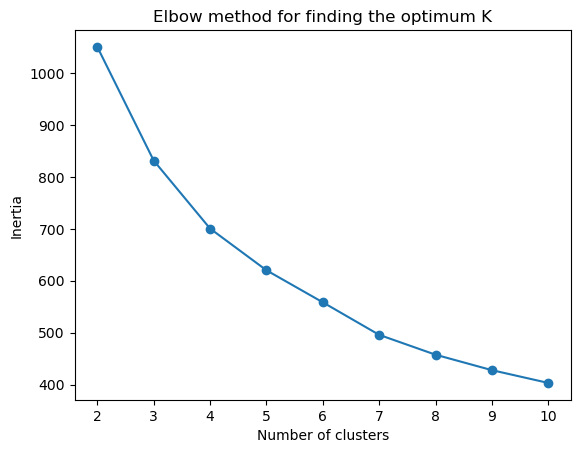

In [58]:
# Let's find the optimum K 
inertias = []
for i in range(2,11):
 kmeans = KMeans(n_clusters=i,n_init=10, random_state=42)
 kmeans.fit(X)
 inertias.append(kmeans.inertia_)
plt.plot(range(2,11), inertias, marker='o')
plt.title('Elbow method for finding the optimum K')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.savefig('Kmeans_optimumK_plot.png')
plt.show()